In [251]:
import numpy as np
from pygmid import Lookup as lk
import matplotlib.pyplot as plt

# Load technology data
NCH = lk('../sky130_lookup/simulation/nfet_01v8_lvt.mat')
PCH = lk('../sky130_lookup/simulation/pfet_01v8_lvt.mat')

In [252]:
# ===================
# 5T-OTA DESIGN SPECS
# ===================
VDD = 1.8             # Supply Voltage (V)
CL  = 2e-12           # Load Capacitance (F)
SR_spec = 1e6         # Slew Rate (V/s)
GBW_spec = 1e6        # Gain Bandwidth (Hz)
Gain_spec_dB = 38     # DC Gain (dB)
Gain_spec = 10**(Gain_spec_dB/20) # Convert dB to V/V
PM_spec = 65          # Phase Margin (degrees)
Power_spec = 10e-6   # Power Consumption (W)

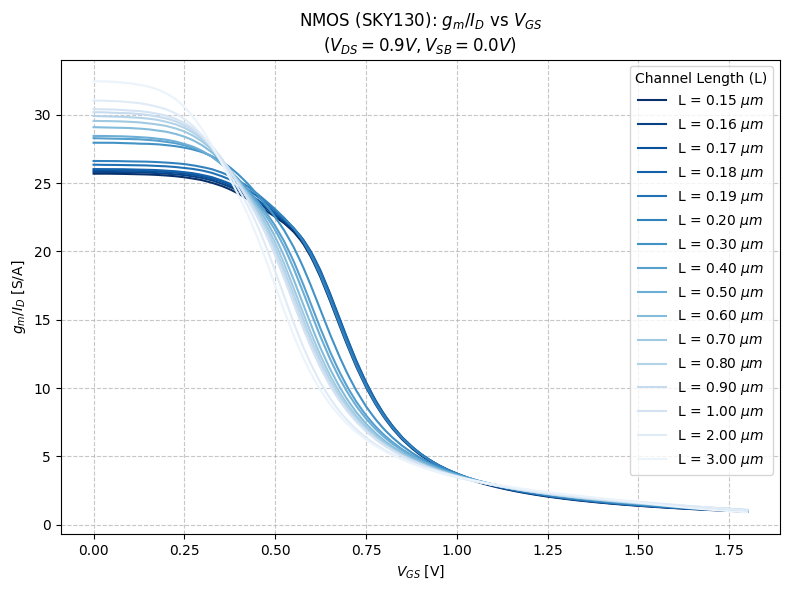

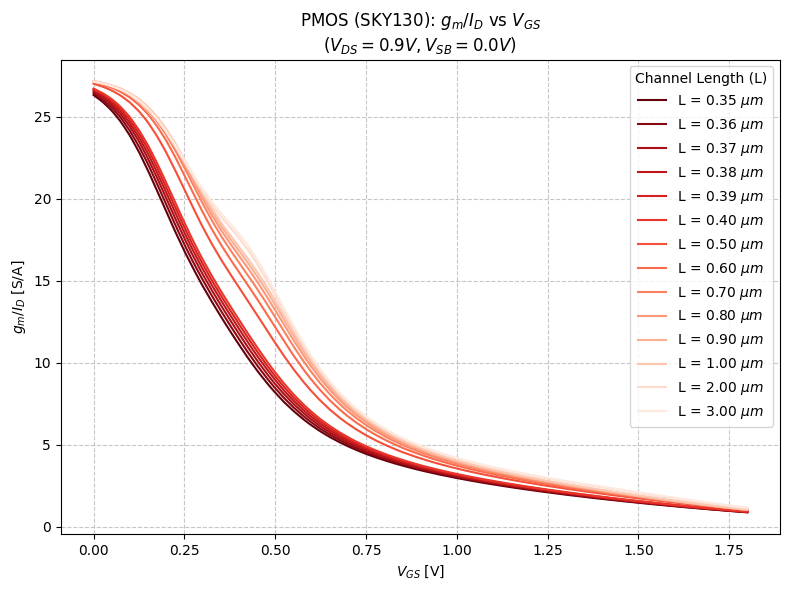

In [253]:
# ==============================
# NMOS & PMOS gm/ID VS VGS PLOTS
# ==============================
# Define Sweep Parameters
VGS_sweep = np.linspace(0, VDD, 200) 
VDS_const = VDD/2  # Set VDS to mid-rail
VSB_const = 0.0  # Source-Bulk voltage

def plot_gmid_vs_vgs(device_data, device_name, color_map):
    plt.figure(figsize=(8, 6))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', vgs=VGS_sweep, VDS=VDS_const, VSB=VSB_const, L=L_val)
        
        # Plotting
        plt.plot(VGS_sweep, gm_ID, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(f'{device_name}: $g_m/I_D$ vs $V_{{GS}}$\n($V_{{DS}}={VDS_const}V, V_{{SB}}={VSB_const}V$)')
    plt.xlabel('$V_{GS}$ [V]')
    plt.ylabel('$g_m/I_D$ [S/A]')
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_gmid_vs_vgs(NCH, "NMOS (SKY130)", plt.cm.Blues_r)
plot_gmid_vs_vgs(PCH, "PMOS (SKY130)", plt.cm.Reds_r)

In [ ]:
# =========================================
# INPUT DESIGN PARAMETERS FOR 5T-OTA SIZING
# =========================================
gm_ID_1 = 18        # S/A
gm_ID_2 = 6         # S/A
L_1 = 0.5           # um
L_2 = 3             # um
ID_margin = 100     # % margin on current calculations

I_tail_min = SR_spec * CL  # Minimum tail current (A)
print(f"Minimum Tail Current (I_tail_min) for SR = {SR_spec*1e-6:.2f}V/μs and CL = {CL*1e12:.2f}pF : {I_tail_min*1e6:.2f}μA")

gm1_min = 2 * np.pi * GBW_spec * CL  # Minimum gm1 for GBW spec
print(f"Minimum gm1 (gm1_min) for GBW = {GBW_spec*1e-6:.2f}MHz and CL = {CL*1e12:.2f}pF : {gm1_min*1e6:.2f}μS")

Minimum Tail Current (I_tail_min) for SR = 1.00V/μs and CL = 2.00pF : 2.00μA
Minimum gm1 (gm1_min) for GBW = 1.00MHz and CL = 2.00pF : 12.57μS


In [255]:
# ==============================
# TRANSISTOR SIZING CALCULATIONS
# ==============================
ID_12 = (I_tail_min / 2) * (1 + ID_margin / 100)  # With % margin for tail current split
print(f"Design Tail Current (ID_tail) with {ID_margin}% margin: {ID_12*1e6*2:.2f}μA")

gm1 = gm_ID_1 * ID_12
if gm1 < gm1_min:
    # Throw an error
    raise ValueError(f"Calculated gm1 ({gm1*1e6:.2f}μS) is less than minimum required gm1 ({gm1_min*1e6:.2f}μS) for GBW spec.")
else:
    print(f"Calculated gm1: {gm1*1e6:.2f}μS")

gm2 = gm_ID_2 * ID_12
print(f"Calculated gm2: {gm2*1e6:.2f}μS")

Vgs_1 = NCH.lookupVGS(GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
print(f"NMOS M1 Vgs at gm/ID={gm_ID_1}S/A and L={L_1}μm : {Vgs_1:.3f}V")

Vgs_2_init = PCH.lookupVGS(GM_ID=gm_ID_2, VSB=0, L=L_2)
Vgs_2 = PCH.lookupVGS(GM_ID=gm_ID_2, VDS=Vgs_2_init, VSB=0, L=L_2)
if np.round(Vgs_2, decimals=2) != np.round(Vgs_2_init, decimals=2):
    raise ValueError(f"PMOS M2 Vgs calculation did not converge. {Vgs_2_init:.2f}V != {Vgs_2:.2f}V")
else:
    print(f"PMOS M2 Vgs at gm/ID={gm_ID_2}S/A and L={L_2}μm : {Vgs_2:.3f}V")

Cdd_1 = gm1 / NCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
Cdd_2 = gm2 / PCH.lookup('GM_CDD', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
Cpar = Cdd_1 + Cdd_2
print(f"Parasitic Capacitance at Output Node (Cpar) : {Cpar*1e15:.2f}fF")
Cload_total = CL + Cpar

JD_1 = NCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

W_1 = ID_12 / JD_1
print(f"NMOS M1 Width (W1) : {W_1:.2f}μm")

W_2 = ID_12 / JD_2
print(f"PMOS M2 Width (W2) : {W_2:.2f}μm")

gds_1 = gm1 / NCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
gds_2 = gm2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

Vth_1 = NCH.lookup('VT', VGS=Vgs_1, VDS=VDD/2, VSB=0, L=L_1)
print(f"NMOS M1 Threshold Voltage (Vth_1) : {Vth_1:.3f}V")

Vth_2 = PCH.lookup('VT', VGS=Vgs_2, VDS=Vgs_2, VSB=0, L=L_2)
print(f"PMOS M2 Threshold Voltage (Vth_2) : {Vth_2:.3f}V")

Design Tail Current (ID_tail) with 100% margin: 4.00μA
Calculated gm1: 36.00μS
Calculated gm2: 12.00μS
NMOS M1 Vgs at gm/ID=18S/A and L=0.5μm : 0.563V
PMOS M2 Vgs at gm/ID=6S/A and L=3μm : 0.800V
Parasitic Capacitance at Output Node (Cpar) : 1.75fF
NMOS M1 Width (W1) : 1.21μm
PMOS M2 Width (W2) : 2.23μm
NMOS M1 Threshold Voltage (Vth_1) : 0.518V
PMOS M2 Threshold Voltage (Vth_2) : 0.438V


In [256]:
# ==================
# SPECS VERIFICATION
# ==================

# Slew Rate Verification
SR_calc = (ID_12 * 2) / Cload_total
if SR_calc < SR_spec:
    raise ValueError(f"Calculated Slew Rate (SR_calc = {SR_calc*1e-6:.2f}V/μs) is less than specified Slew Rate (SR_spec = {SR_spec*1e-6:.2f}V/μs).")
else:
    print(f"Slew Rate : {SR_calc*1e-6:.2f}V/μs")

# Gain Bandwidth Verification
GBW_calc = gm1 / (2 * np.pi * Cload_total)
if GBW_calc < GBW_spec:
    raise ValueError(f"Calculated Gain Bandwidth (GBW_calc = {GBW_calc*1e-6:.2f}MHz) is less than specified Gain Bandwidth (GBW_spec = {GBW_spec*1e-6:.2f}MHz).")
else:
    print(f"Gain Bandwidth : {GBW_calc*1e-6:.2f}MHz")

# Gain Verification
Gain_calc = gm1 / (gds_1 + gds_2)
if Gain_calc < Gain_spec:
    raise ValueError(f"Calculated Gain (Gain_calc = {20*np.log10(Gain_calc):.2f}dB) is less than specified Gain (Gain_spec = {Gain_spec_dB}dB).")
else:
    print(f"Gain : {20*np.log10(Gain_calc):.2f}dB")

# Phase Margin (degrees) Verification
PM_calc = 90 - (np.arctan(GBW_calc / (gm2 / Cpar))*(180/np.pi))
if PM_calc < PM_spec:
    raise ValueError(f"Calculated Phase Margin (PM_calc = {PM_calc:.2f} degrees) is less than specified Phase Margin (PM_spec = {PM_spec} degrees).")
else:
    print(f"Phase Margin : {PM_calc:.2f} degrees")

# Power Consumption Verification
Power_calc = ID_12 * 2 * VDD
if Power_calc > Power_spec:
    raise ValueError(f"Calculated Power Consumption (Power_calc = {Power_calc*1e6:.2f}μW) exceeds specified Power Consumption (Power_spec = {Power_spec*1e6:.2f}μW).")
else:
    print(f"Power Consumption : {Power_calc*1e6:.2f}μW")

# Active area calculation
Area_active = 2 * ((W_1 * L_1) + (W_2 * L_2))
print(f"\nTotal Active Area of 5T-OTA : {Area_active:.2f}μm²")

Slew Rate : 2.00V/μs
Gain Bandwidth : 2.86MHz
Gain : 38.10dB
Phase Margin : 89.98 degrees
Power Consumption : 7.20μW

Total Active Area of 5T-OTA : 14.58μm²
